# Progression Prediction Results Analysis (progression_prediction.py)

This notebook analyzes runs produced by `src/models/progression_prediction.py` (late-fusion progression models).
It scans one or more results folders, summarizes train/val/test metrics, and plots:
- best runs per ResNet and fusion mode,
- validation vs test performance,
- learning curves and confusion matrices for a selected run.


In [1]:
from pathlib import Path
import json
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

# Config
RESULTS_ROOT = Path("src/models/results_fusion")
RUN_ROOT = None  # e.g., Path("src/models/results_fusion/prog-rgb-apple-resnet18-sum-lr3e-04-wd1e-04-20260114-095047")
MERGE_ALL = True
EXTRA_RUN_DIRS = []  # Optional list of explicit run directories

plt.style.use("seaborn-v0_8-whitegrid")


In [2]:
def _candidate_roots():
    roots = []
    if RESULTS_ROOT is not None:
        roots.append(Path(RESULTS_ROOT))
    cwd = Path.cwd()
    roots.extend(
        [
            cwd / "src/models/results_fusion",
            cwd.parent / "src/models/results_fusion",
            cwd,
            cwd.parent,
        ]
    )
    seen = set()
    uniq = []
    for root in roots:
        try:
            resolved = root.resolve()
        except FileNotFoundError:
            continue
        if resolved not in seen:
            uniq.append(resolved)
            seen.add(resolved)
    return [r for r in uniq if r.exists()]

def collect_run_dirs():
    if RUN_ROOT is not None:
        run_dir = Path(RUN_ROOT)
        if not run_dir.exists():
            raise FileNotFoundError(f"RUN_ROOT not found: {run_dir}")
        return [run_dir]

    run_dirs = []
    if MERGE_ALL:
        for root in _candidate_roots():
            run_dirs.extend(p.parent for p in root.rglob("metrics_epoch.json"))

    for extra in EXTRA_RUN_DIRS:
        p = Path(extra)
        if p.exists():
            run_dirs.append(p)

    run_dirs = sorted(set(run_dirs))
    if not run_dirs:
        raise FileNotFoundError("No runs found. Set RUN_ROOT or update RESULTS_ROOT/EXTRA_RUN_DIRS.")
    return run_dirs

run_dirs = collect_run_dirs()
print(f"Found {len(run_dirs)} run(s)")
for p in run_dirs[:10]:
    print("-", p)
if len(run_dirs) > 10:
    print("...")


Found 7 run(s)
- /home/hemamgholizadeh/hippa-rgb/src/models/results_fusion/prog-rgb-apple-concat-20260113-133533
- /home/hemamgholizadeh/hippa-rgb/src/models/results_fusion/prog-rgb-apple-concat_sum_prod-20260113-154452
- /home/hemamgholizadeh/hippa-rgb/src/models/results_fusion/prog-rgb-apple-prod-20260113-112748
- /home/hemamgholizadeh/hippa-rgb/src/models/results_fusion/prog-rgb-apple-resnet18-concat-lr3e-04-wd1e-04-20260114-120607
- /home/hemamgholizadeh/hippa-rgb/src/models/results_fusion/prog-rgb-apple-resnet18-prod-lr3e-04-wd1e-04-20260114-111633
- /home/hemamgholizadeh/hippa-rgb/src/models/results_fusion/prog-rgb-apple-resnet18-sum-lr3e-04-wd1e-04-20260114-095047
- /home/hemamgholizadeh/hippa-rgb/src/models/results_fusion/prog-rgb-apple-sum-20260113-092013


In [3]:
def read_json(path):
    path = Path(path)
    if not path.exists():
        return None
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

def parse_run_name(name):
    info = {"resnet": None, "fusion_mode": None, "lr": None, "wd": None, "timestamp": None}
    match = re.match(r"^prog-rgb-apple-(?:(resnet\d+)-)?([a-z_]+)(.*)$", name)
    if not match:
        return info
    info["resnet"] = match.group(1)
    info["fusion_mode"] = match.group(2)
    rest = match.group(3) or ""
    lr_match = re.search(r"-lr(.+?)-wd(.+?)-(?P<ts>\d{8}-\d{6})$", rest)
    if lr_match:
        info["lr"] = lr_match.group(1)
        info["wd"] = lr_match.group(2)
        info["timestamp"] = lr_match.group("ts")
        return info
    ts_match = re.search(r"-(\d{8}-\d{6})$", rest)
    if ts_match:
        info["timestamp"] = ts_match.group(1)
    return info

def summarize_run(run_dir):
    run_dir = Path(run_dir)
    info = parse_run_name(run_dir.name)
    history = read_json(run_dir / "metrics_epoch.json") or {}

    summary = {
        "run_name": run_dir.name,
        "run_dir": str(run_dir),
        **info,
        "epochs": len(history.get("train_loss", [])),
        "best_val_acc": max(history.get("val_acc", []) or [np.nan]),
        "best_val_loss": min(history.get("val_loss", []) or [np.nan]),
        "final_val_acc": history.get("val_acc", [np.nan])[-1] if history.get("val_acc") else np.nan,
        "final_train_acc": history.get("train_acc", [np.nan])[-1] if history.get("train_acc") else np.nan,
    }

    for split in ("train", "val", "test"):
        data = read_json(run_dir / f"{split}_results.json")
        if isinstance(data, dict):
            summary[f"{split}_acc"] = data.get("acc", np.nan)
            summary[f"{split}_loss"] = data.get("loss", np.nan)
            labels = data.get("labels") or []
            summary[f"{split}_n"] = len(labels) if isinstance(labels, list) else np.nan

    return summary

rows = [summarize_run(p) for p in run_dirs]
df = pd.DataFrame(rows)

df["resnet"] = df["resnet"].fillna("unknown")
df["fusion_mode"] = df["fusion_mode"].fillna("unknown")
df["metric"] = df["val_acc"].fillna(df["best_val_acc"])

df = df.sort_values("metric", ascending=False)
df.head(10)


,run_name,run_dir,resnet,fusion_mode,lr,wd,timestamp,epochs,best_val_acc,best_val_loss,...,train_acc,train_loss,train_n,val_acc,val_loss,val_n,test_acc,test_loss,test_n,metric
6,prog-rgb-apple-sum-20260113-092013,/home/hemamgholizadeh/hippa-rgb/src/models/res...,unknown,sum,None,None,20260113-092013,20,0.824306,0.462050,...,0.985749,0.040998,6596.0,0.804861,0.545346,1440.0,0.804861,0.545346,1440.0,0.804861
2,prog-rgb-apple-prod-20260113-112748,/home/hemamgholizadeh/hippa-rgb/src/models/res...,unknown,prod,None,None,20260113-112748,20,0.800000,0.479669,...,0.987113,0.038666,6596.0,0.793750,0.623839,1440.0,0.793750,0.623839,1440.0,0.793750
0,prog-rgb-apple-concat-20260113-133533,/home/hemamgholizadeh/hippa-rgb/src/models/res...,unknown,concat,None,None,20260113-133533,20,0.819444,0.486560,...,0.984384,0.046896,6596.0,0.786806,0.665256,1440.0,0.786806,0.665256,1440.0,0.786806
3,prog-rgb-apple-resnet18-concat-lr3e-04-wd1e-04...,/home/hemamgholizadeh/hippa-rgb/src/models/res...,resnet18,concat,3e-04,1e-04,20260114-120607,14,0.777778,0.519213,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.777778
4,prog-rgb-apple-resnet18-prod-lr3e-04-wd1e-04-2...,/home/hemamgholizadeh/hippa-rgb/src/models/res...,resnet18,prod,3e-04,1e-04,20260114-111633,7,0.776389,0.539603,...,0.878714,0.266824,6596.0,0.776389,0.564610,1440.0,0.776389,0.564610,1440.0,0.776389
1,prog-rgb-apple-concat_sum_prod-20260113-154452,/home/hemamgholizadeh/hippa-rgb/src/models/res...,unknown,concat_sum_prod,None,None,20260113-154452,20,0.793750,0.506014,...,0.954215,0.133148,6596.0,0.770833,0.782129,1440.0,0.770833,0.782129,1440.0,0.770833
5,prog-rgb-apple-resnet18-sum-lr3e-04-wd1e-04-20...,/home/hemamgholizadeh/hippa-rgb/src/models/res...,resnet18,sum,3e-04,1e-04,20260114-095047,13,0.787500,0.520221,...,0.923287,0.178858,6596.0,0.760417,0.800291,1440.0,0.760417,0.800291,1440.0,0.760417


In [4]:
cols = [
    "run_name",
    "resnet",
    "fusion_mode",
    "lr",
    "wd",
    "metric",
    "val_acc",
    "test_acc",
    "best_val_loss",
    "epochs",
]
df[cols]


,run_name,resnet,fusion_mode,lr,wd,metric,val_acc,test_acc,best_val_loss,epochs
6,prog-rgb-apple-sum-20260113-092013,unknown,sum,None,None,0.804861,0.804861,0.804861,0.462050,20
2,prog-rgb-apple-prod-20260113-112748,unknown,prod,None,None,0.793750,0.793750,0.793750,0.479669,20
0,prog-rgb-apple-concat-20260113-133533,unknown,concat,None,None,0.786806,0.786806,0.786806,0.486560,20
3,prog-rgb-apple-resnet18-concat-lr3e-04-wd1e-04...,resnet18,concat,3e-04,1e-04,0.777778,NaN,NaN,0.519213,14
4,prog-rgb-apple-resnet18-prod-lr3e-04-wd1e-04-2...,resnet18,prod,3e-04,1e-04,0.776389,0.776389,0.776389,0.539603,7
1,prog-rgb-apple-concat_sum_prod-20260113-154452,unknown,concat_sum_prod,None,None,0.770833,0.770833,0.770833,0.506014,20
5,prog-rgb-apple-resnet18-sum-lr3e-04-wd1e-04-20...,resnet18,sum,3e-04,1e-04,0.760417,0.760417,0.760417,0.520221,13


In [5]:
def select_best(group):
    group = group.copy()
    if group["metric"].notna().any():
        return group.loc[group["metric"].idxmax()]
    return group.iloc[0]

best_rows = []
for (resnet, fusion), group in df.groupby(["resnet", "fusion_mode"]):
    best_rows.append(select_best(group))

best_df = pd.DataFrame(best_rows).sort_values(["resnet", "fusion_mode"])
best_df[["resnet", "fusion_mode", "metric", "val_acc", "test_acc", "run_name"]]


,resnet,fusion_mode,metric,val_acc,test_acc,run_name
3,resnet18,concat,0.777778,NaN,NaN,prog-rgb-apple-resnet18-concat-lr3e-04-wd1e-04...
4,resnet18,prod,0.776389,0.776389,0.776389,prog-rgb-apple-resnet18-prod-lr3e-04-wd1e-04-2...
5,resnet18,sum,0.760417,0.760417,0.760417,prog-rgb-apple-resnet18-sum-lr3e-04-wd1e-04-20...
0,unknown,concat,0.786806,0.786806,0.786806,prog-rgb-apple-concat-20260113-133533
1,unknown,concat_sum_prod,0.770833,0.770833,0.770833,prog-rgb-apple-concat_sum_prod-20260113-154452
2,unknown,prod,0.793750,0.793750,0.793750,prog-rgb-apple-prod-20260113-112748
6,unknown,sum,0.804861,0.804861,0.804861,prog-rgb-apple-sum-20260113-092013


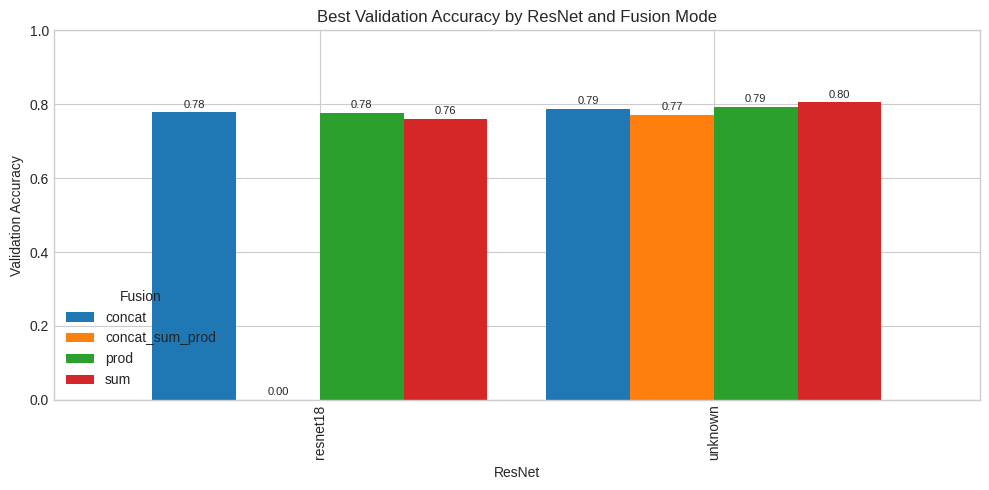

In [6]:
def annotate_bars(ax):
    for bar in ax.patches:
        height = bar.get_height()
        if np.isnan(height):
            continue
        ax.annotate(
            f"{height:.2f}",
            (bar.get_x() + bar.get_width() / 2, height),
            ha="center",
            va="bottom",
            fontsize=8,
            xytext=(0, 2),
            textcoords="offset points",
        )

plot_df = best_df.pivot(index="resnet", columns="fusion_mode", values="metric")
plot_df = plot_df.sort_index()

ax = plot_df.plot(kind="bar", figsize=(10, 5), width=0.85)
ax.set_title("Best Validation Accuracy by ResNet and Fusion Mode")
ax.set_xlabel("ResNet")
ax.set_ylabel("Validation Accuracy")
ax.set_ylim(0.0, 1.0)
ax.legend(title="Fusion")
annotate_bars(ax)
plt.tight_layout()
plt.show()


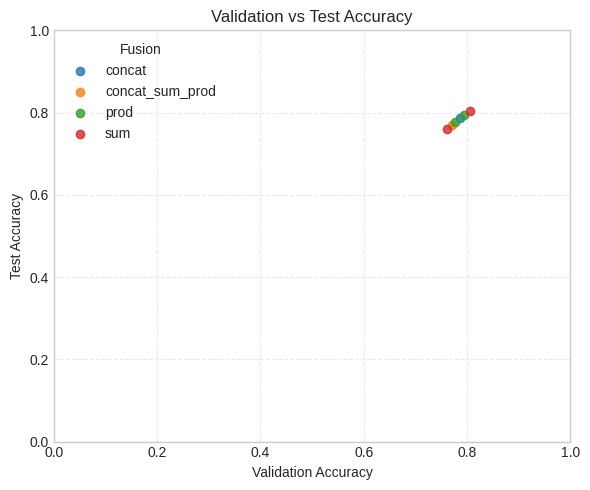

In [7]:
valid = df.dropna(subset=["metric", "test_acc"]).copy()
fig, ax = plt.subplots(figsize=(6, 5))
for fusion, group in valid.groupby("fusion_mode"):
    ax.scatter(group["metric"], group["test_acc"], label=fusion, alpha=0.8)
ax.set_xlabel("Validation Accuracy")
ax.set_ylabel("Test Accuracy")
ax.set_title("Validation vs Test Accuracy")
ax.set_xlim(0.0, 1.0)
ax.set_ylim(0.0, 1.0)
ax.legend(title="Fusion")
ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


Focus run: /home/hemamgholizadeh/hippa-rgb/src/models/results_fusion/prog-rgb-apple-sum-20260113-092013


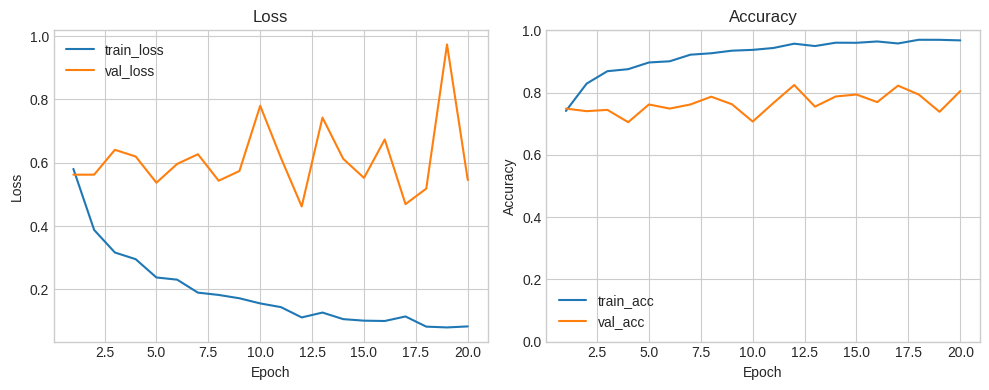

In [8]:
FOCUS_RUN = None  # set to a run_dir or run_name

def resolve_focus_run(focus, df):
    if focus is None:
        if df.empty:
            return None
        return Path(df.iloc[0]["run_dir"])
    focus_path = Path(focus)
    if focus_path.exists():
        return focus_path
    match = df[df["run_name"] == str(focus)]
    if not match.empty:
        return Path(match.iloc[0]["run_dir"])
    return None

focus_dir = resolve_focus_run(FOCUS_RUN, df)
print("Focus run:", focus_dir if focus_dir else "None")

history = read_json(focus_dir / "metrics_epoch.json") if focus_dir else None
if history:
    epochs = range(1, len(history.get("train_loss", [])) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].plot(epochs, history.get("train_loss", []), label="train_loss")
    axes[0].plot(epochs, history.get("val_loss", []), label="val_loss")
    axes[0].set_title("Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()

    axes[1].plot(epochs, history.get("train_acc", []), label="train_acc")
    axes[1].plot(epochs, history.get("val_acc", []), label="val_acc")
    axes[1].set_title("Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].set_ylim(0.0, 1.0)
    axes[1].legend()

    plt.tight_layout()
    plt.show()
else:
    print("No metrics_epoch.json found for focus run.")


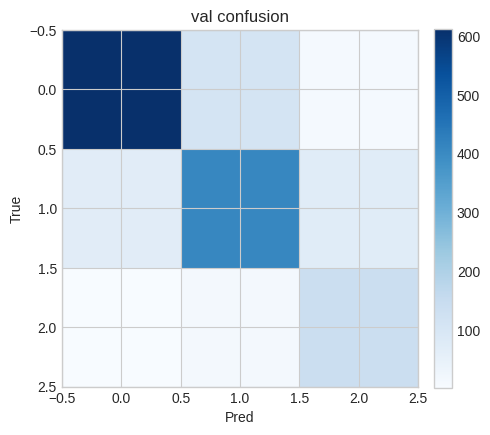

val per-class accuracy


class
0    0.836066
1    0.740942
2    0.884615
Name: acc, dtype: float64

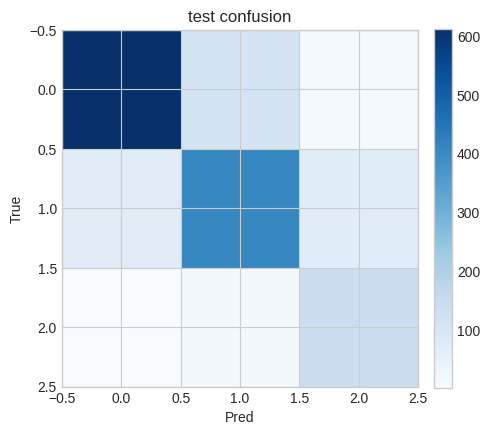

test per-class accuracy


class
0    0.836066
1    0.740942
2    0.884615
Name: acc, dtype: float64

In [9]:
def confusion_from_results(results_path):
    data = read_json(results_path)
    if not isinstance(data, dict):
        return None
    labels = np.array(data.get("labels", []))
    preds = np.array(data.get("preds", []))
    if labels.size == 0:
        return None
    n = int(max(labels.max(), preds.max()) + 1)
    cm = np.zeros((n, n), dtype=int)
    for t, p in zip(labels, preds):
        cm[int(t), int(p)] += 1
    return cm

def plot_confusion(cm, title):
    fig, ax = plt.subplots(figsize=(5, 5))
    im = ax.imshow(cm, cmap="Blues")
    ax.set_title(title)
    ax.set_xlabel("Pred")
    ax.set_ylabel("True")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

def per_class_accuracy(cm):
    with np.errstate(divide="ignore", invalid="ignore"):
        acc = np.diag(cm) / cm.sum(axis=1)
    return pd.Series(acc).rename("acc")

if focus_dir:
    for split in ("val", "test"):
        cm = confusion_from_results(focus_dir / f"{split}_results.json")
        if cm is None:
            print(f"No {split}_results.json with labels/preds for {focus_dir}")
            continue
        plot_confusion(cm, f"{split} confusion")
        per_class = per_class_accuracy(cm)
        per_class.index.name = "class"
        print(f"{split} per-class accuracy")
        display(per_class)
